# A Catholic Introduction to Artificial Intelligence
## Final Project — Module 1: Getting to Know the Data
### Classes 1 & 2

---

> *"We must lovingly safeguard the grandeur of humanity bestowed upon us and revealed in its fullness in Christ, the splendor of which no machine can ever replace."*
> — Pope Leo XIV, *Magnifica Humanitas*, no. 15

---

## Project Overview

Over the course of this class, you will build an AI system step by step — and at each stage, you will interrogate what you have built from a Catholic ethical perspective.

**The central question:** Can an AI system predict whether a student will complete homework on time? And if it can — *should* it?

This module covers the first and most important step in any AI project: **understanding your data**. Before building any model, a responsible AI practitioner must know what they are working with — what every variable means, what patterns exist, and — crucially — what the data *cannot* tell you about the human beings it represents.

### What You Will Do in This Module

1. Load the dataset and examine its structure
2. Understand what each variable measures
3. Identify patterns and distributions in the data
4. Begin asking the ethical questions that this data raises

---

In [14]:
# Install the necessary libraries if you haven't already'
%pip install pandas seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 1: Loading the Data

We begin by importing the tools we need and loading the dataset.

**pandas** is a Python library for working with tabular data — think of it as a programmable spreadsheet.  
**matplotlib** and **seaborn** are Python libraries for creating charts and visualizations.

In [15]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Load the dataset
# If running locally, update this path to where you saved the CSV file
df = pd.read_csv('synthetic_homework_dataset.csv')

print(f'Dataset loaded successfully.')
print(f'Rows: {len(df)}')
print(f'Columns: {len(df.columns)}')

Dataset loaded successfully.
Rows: 500
Columns: 15


## Part 2: What Does the Data Contain?

Let's look at the first several rows to get a sense of the structure.

In [16]:
# Show the first 8 rows
df.head(8)

,student_id,assignment_id,assignment_type,num_questions,difficulty,days_until_due,date_assigned,date_submitted,time_spent_minutes,num_work_sessions,completed_on_time,submitted_late_days,prior_completion_rate,prior_avg_grade,prior_avg_homework_time
0,S140,A8,reading,19,4,3,2026-02-17,2026-02-20,45.5,1,1,0,0.73,100.0,39.1
1,S117,A16,worksheet,5,5,4,2026-01-09,2026-01-17,65.7,1,0,4,0.80,60.0,49.5
2,S147,A7,quiz_prep,20,4,6,2026-01-06,2026-01-15,73.9,1,0,3,0.79,91.0,65.6
3,S137,A28,reading,8,2,1,2026-01-02,2026-01-02,28.5,1,1,0,1.00,79.0,49.5
4,S105,A14,worksheet,12,4,3,2026-02-02,2026-02-03,38.4,1,1,0,0.93,72.8,42.1
5,S138,A2,quiz_prep,18,4,6,2026-01-13,2026-01-14,71.7,2,1,0,0.75,90.6,40.3
6,S145,A35,essay,17,1,1,2026-01-15,2026-01-19,60.8,2,0,3,0.91,93.9,48.9
7,S128,A38,coding,12,1,4,2026-02-21,2026-02-23,48.5,3,1,0,0.87,82.5,32.3


### What Each Column Means

Each **row** in this dataset represents one student completing one assignment. Here is what each column records:

| Column | Type | What It Measures |
|--------|------|------------------|
| `student_id` | ID | A unique identifier for each student (e.g. S140) |
| `assignment_id` | ID | A unique identifier for each assignment (e.g. A8) |
| `assignment_type` | Category | Type of work: reading, worksheet, quiz_prep, essay, coding |
| `num_questions` | Number | How many questions or items the assignment contained |
| `difficulty` | Scale 1–5 | How hard the assignment was (1 = easy, 5 = very hard) |
| `days_until_due` | Number | How many days the student had to complete it |
| `date_assigned` | Date | When the assignment was given |
| `date_submitted` | Date | When the student actually submitted it |
| `time_spent_minutes` | Number | How many minutes the student spent on it |
| `num_work_sessions` | Number | How many separate sittings the student worked on it |
| `completed_on_time` | 0 or 1 | Whether it was submitted on time (1 = yes, 0 = no) |
| `submitted_late_days` | Number | How many days late it was (0 if on time) |
| `prior_completion_rate` | 0.0–1.0 | Fraction of *previous* assignments this student completed on time |
| `prior_avg_grade` | Number | This student's average grade on previous assignments |
| `prior_avg_homework_time` | Number | How long this student typically spends on homework (historical average) |

---

> 🤔 **Think about it:** `completed_on_time` is the variable our AI will eventually try to **predict**. In machine learning, this is called the **target variable** or **label**. Every other column is a potential **feature** — information the model will use to make its prediction.
>
> Before we write a single line of model code, spend a moment thinking: if you were a teacher trying to predict which students might struggle to submit on time, which of these columns would you pay most attention to? Which feel most relevant — and which feel like they might not tell the whole story?

## Part 3: The Shape and Structure of the Data

In [17]:
# How many unique students and assignments are there?
print(f"Total rows (student-assignment pairs): {len(df)}")
print(f"Unique students: {df['student_id'].nunique()}")
print(f"Unique assignments: {df['assignment_id'].nunique()}")
print()

# What types of assignments are in the dataset?
print("Assignment types and how many of each:")
print(df['assignment_type'].value_counts())
print()

# What is the overall on-time completion rate?
rate = df['completed_on_time'].mean() * 100
print(f"Overall on-time completion rate: {rate:.1f}%")

Total rows (student-assignment pairs): 500
Unique students: 51
Unique assignments: 40

Assignment types and how many of each:
assignment_type
reading      106
worksheet    104
essay        103
quiz_prep     94
coding        93
Name: count, dtype: int64

Overall on-time completion rate: 85.8%


In [18]:
# Check for missing values — important before any analysis
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — the dataset is complete.")

Missing values per column:
None — the dataset is complete.


In [19]:
# Summary statistics for all numeric columns
df.describe().round(2)

,num_questions,difficulty,days_until_due,time_spent_minutes,num_work_sessions,completed_on_time,submitted_late_days,prior_completion_rate,prior_avg_grade,prior_avg_homework_time
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,14.89,3.05,3.54,58.24,1.66,0.86,0.38,0.85,84.81,40.55
std,5.80,1.43,1.76,24.73,0.77,0.35,1.04,0.10,8.91,10.03
min,5.00,1.00,1.00,8.90,1.00,0.00,0.00,0.52,60.00,11.30
25%,10.00,2.00,2.00,40.18,1.00,1.00,0.00,0.78,79.00,33.70
50%,15.00,3.00,4.00,55.50,1.00,1.00,0.00,0.85,85.00,39.90
75%,20.00,4.00,5.00,72.43,2.00,1.00,0.00,0.92,91.00,47.20
max,24.00,5.00,6.00,145.90,5.00,1.00,4.00,1.00,100.00,72.50


### Reading the Summary Statistics

The table above gives us a quick statistical portrait of the dataset. Some things worth noticing:

- **`difficulty`** ranges from 1 to 5, with a mean around 3 — assignments are spread across the difficulty range
- **`time_spent_minutes`** varies widely — some assignments take far less time than others
- **`prior_completion_rate`** has a mean around 0.85 — most students in this dataset have a strong track record
- **`submitted_late_days`** has a mean close to 0 but a max of 4 — most submissions are on time, but some are significantly late

---

## Part 4: Visualizing the Data

Numbers alone are hard to interpret. Charts help us see patterns that would otherwise be invisible. Let's build several visualizations to explore the dataset.

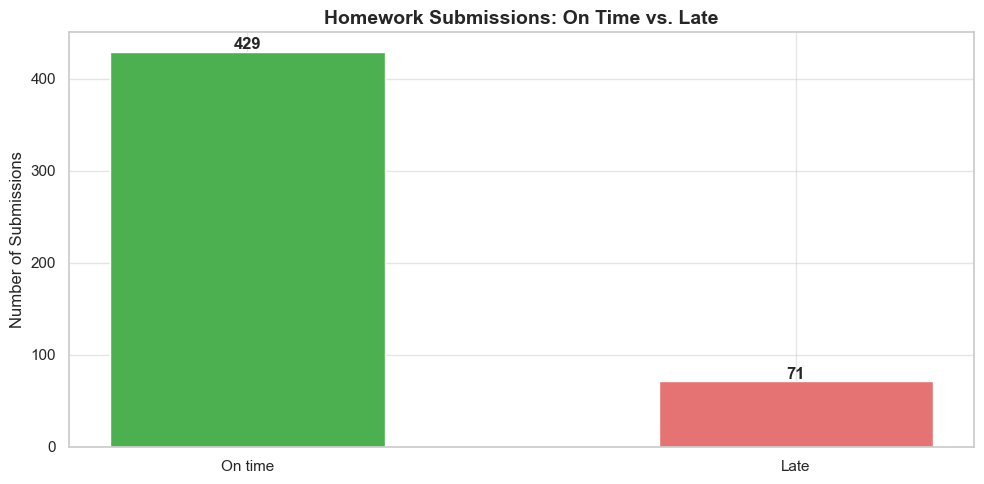

On time: 429 (85.8%)
Late:    71 (14.2%)


In [20]:
# --- Chart 1: On-time vs. late submission ---
fig, ax = plt.subplots()
counts = df['completed_on_time'].value_counts()
labels = ['On time', 'Late']
colors = ['#4CAF50', '#E57373']
ax.bar(labels, [counts.get(1, 0), counts.get(0, 0)], color=colors, width=0.5)
ax.set_title('Homework Submissions: On Time vs. Late', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Submissions')
for i, v in enumerate([counts.get(1, 0), counts.get(0, 0)]):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"On time: {counts.get(1,0)} ({counts.get(1,0)/len(df)*100:.1f}%)")
print(f"Late:    {counts.get(0,0)} ({counts.get(0,0)/len(df)*100:.1f}%)")

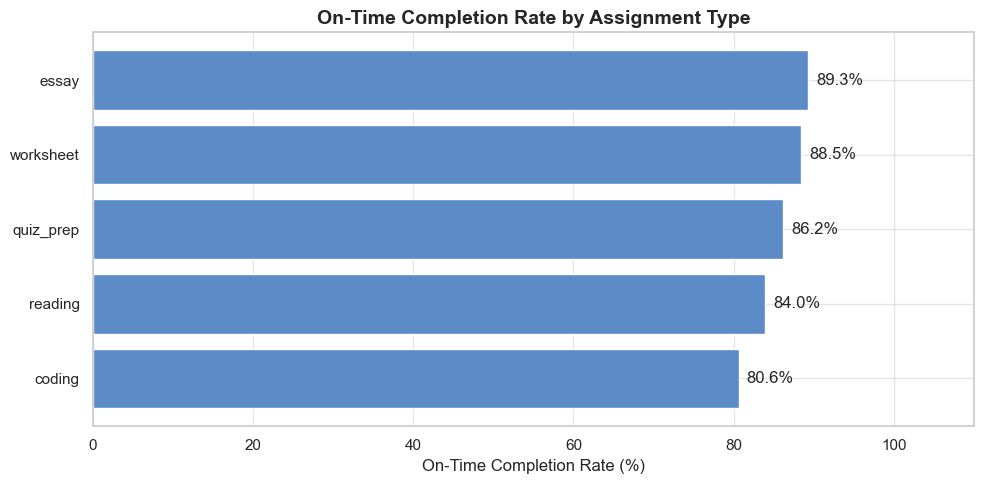

In [21]:
# --- Chart 2: On-time completion rate by assignment type ---
completion_by_type = df.groupby('assignment_type')['completed_on_time'].mean().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(completion_by_type.index, completion_by_type.values * 100, color='#5C8BC7')
ax.set_xlabel('On-Time Completion Rate (%)')
ax.set_title('On-Time Completion Rate by Assignment Type', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
for bar, val in zip(bars, completion_by_type.values):
    ax.text(val * 100 + 1, bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center')
plt.tight_layout()
plt.show()

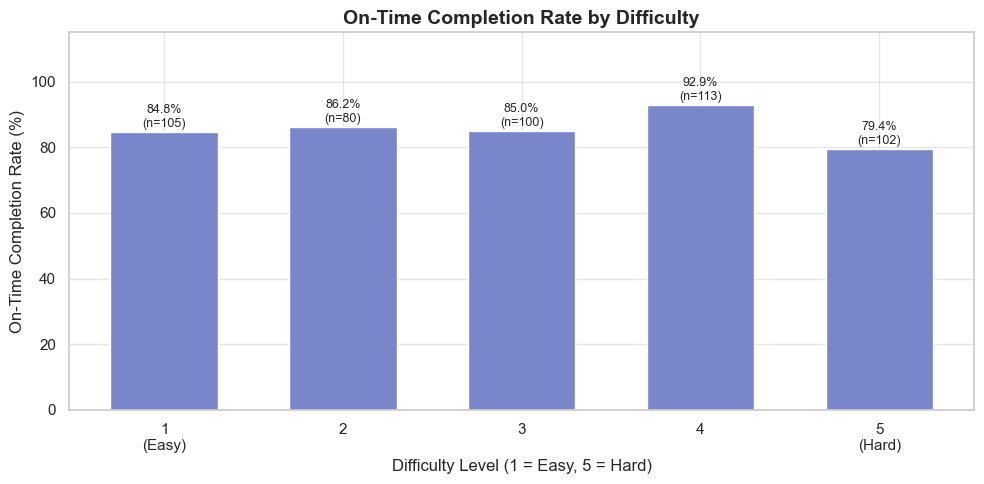

In [22]:
# --- Chart 3: On-time completion rate by difficulty level ---
completion_by_diff = df.groupby('difficulty')['completed_on_time'].mean()
counts_by_diff = df.groupby('difficulty').size()

fig, ax = plt.subplots()
bars = ax.bar(completion_by_diff.index, completion_by_diff.values * 100, color='#7986CB', width=0.6)
ax.set_xlabel('Difficulty Level (1 = Easy, 5 = Hard)')
ax.set_ylabel('On-Time Completion Rate (%)')
ax.set_title('On-Time Completion Rate by Difficulty', fontsize=14, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\n(Easy)', '2', '3', '4', '5\n(Hard)'])
for bar, val, n in zip(bars, completion_by_diff.values, counts_by_diff.values):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + 1.5,
            f'{val*100:.1f}%\n(n={n})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

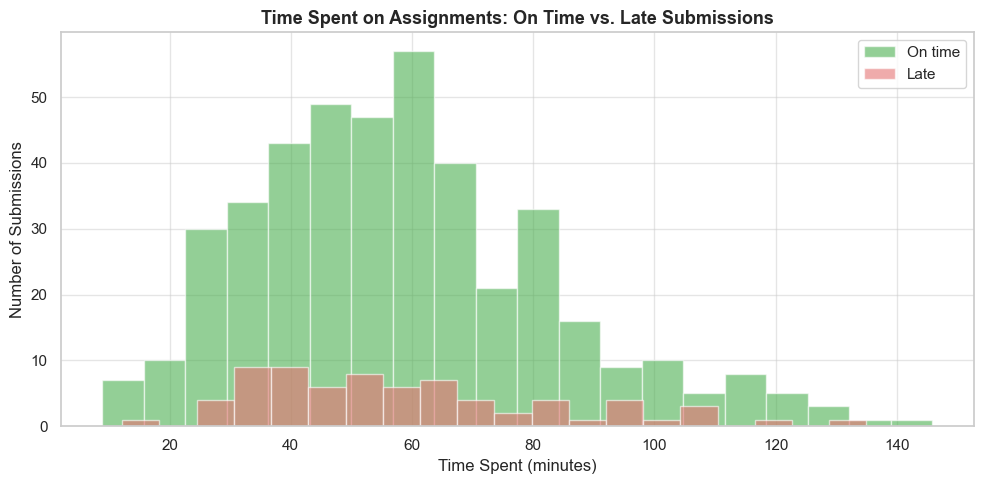

Average time spent:
completed_on_time
Late       59.0
On time    58.1
Name: time_spent_minutes, dtype: float64


In [23]:
# --- Chart 4: Distribution of time spent, by on-time status ---
fig, ax = plt.subplots()
for label, color, name in [(1, '#4CAF50', 'On time'), (0, '#E57373', 'Late')]:
    subset = df[df['completed_on_time'] == label]['time_spent_minutes']
    ax.hist(subset, bins=20, alpha=0.6, color=color, label=name)
ax.set_xlabel('Time Spent (minutes)')
ax.set_ylabel('Number of Submissions')
ax.set_title('Time Spent on Assignments: On Time vs. Late Submissions', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Average time spent:")
print(df.groupby('completed_on_time')['time_spent_minutes'].mean().rename({0: 'Late', 1: 'On time'}).round(1))

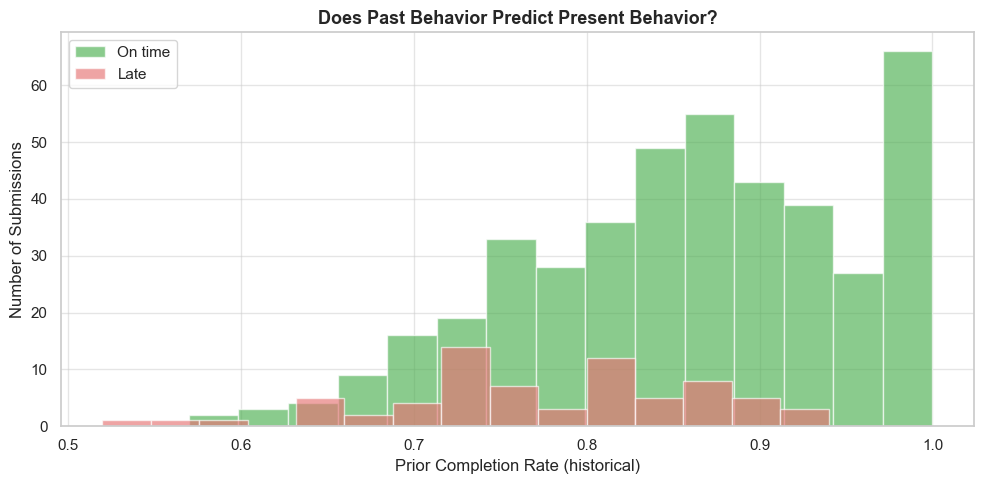

Average prior completion rate:
completed_on_time
Late       0.776
On time    0.860
Name: prior_completion_rate, dtype: float64


In [24]:
# --- Chart 5: Prior completion rate vs. current on-time status ---
fig, ax = plt.subplots()
for label, color, name in [(1, '#4CAF50', 'On time'), (0, '#E57373', 'Late')]:
    subset = df[df['completed_on_time'] == label]['prior_completion_rate']
    ax.hist(subset, bins=15, alpha=0.65, color=color, label=name)
ax.set_xlabel('Prior Completion Rate (historical)')
ax.set_ylabel('Number of Submissions')
ax.set_title('Does Past Behavior Predict Present Behavior?', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Average prior completion rate:")
print(df.groupby('completed_on_time')['prior_completion_rate'].mean().rename({0: 'Late', 1: 'On time'}).round(3))

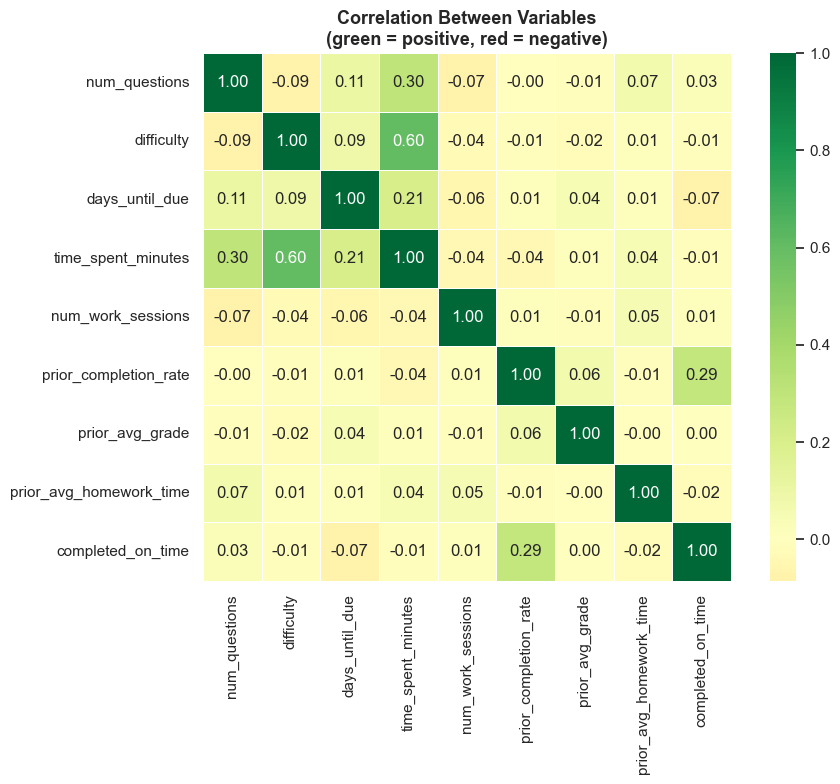


Correlations with completed_on_time (sorted):
prior_completion_rate      0.291
num_questions              0.030
num_work_sessions          0.008
prior_avg_grade            0.004
time_spent_minutes        -0.012
difficulty                -0.013
prior_avg_homework_time   -0.024
days_until_due            -0.073
Name: completed_on_time, dtype: float64


In [25]:
# --- Chart 6: Correlation heatmap of numeric features ---
numeric_cols = [
    'num_questions', 'difficulty', 'days_until_due',
    'time_spent_minutes', 'num_work_sessions',
    'prior_completion_rate', 'prior_avg_grade',
    'prior_avg_homework_time', 'completed_on_time'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Between Variables\n(green = positive, red = negative)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelations with completed_on_time (sorted):")
print(corr['completed_on_time'].drop('completed_on_time').sort_values(ascending=False).round(3))

### Reading the Correlation Heatmap

A **correlation** tells us how strongly two variables move together:

- **+1.0** = perfect positive relationship (as one goes up, the other goes up)
- **0.0** = no relationship
- **-1.0** = perfect negative relationship (as one goes up, the other goes down)

The last column and row — `completed_on_time` — shows which variables are most associated with submitting on time.

---

> 🤔 **Activity:** Look at the correlations with `completed_on_time`. Which variables have the strongest relationship (positive or negative) with whether an assignment was submitted on time?
>
> Write your observations here:
>
> *[Your answer here]*

## Part 5: A Closer Look at Individual Students

In [26]:
# --- Per-student summary ---
student_summary = df.groupby('student_id').agg(
    assignments_total=('completed_on_time', 'count'),
    on_time_rate=('completed_on_time', 'mean'),
    avg_time_spent=('time_spent_minutes', 'mean'),
    avg_difficulty=('difficulty', 'mean'),
    prior_avg_grade=('prior_avg_grade', 'mean')
).round(2)

print(f"Student summary ({len(student_summary)} students):")
print(student_summary.sort_values('on_time_rate').head(10))

Student summary (51 students):
            assignments_total  on_time_rate  avg_time_spent  avg_difficulty  \
student_id                                                                    
S145                       10          0.50           54.55            2.50   
S134                       12          0.58           71.45            3.58   
S121                        9          0.67           49.91            2.44   
S117                        9          0.67           53.87            3.56   
S147                        9          0.67           45.58            2.67   
S142                       16          0.69           59.76            3.06   
S126                       10          0.70           42.95            2.60   
S148                       10          0.70           64.66            3.20   
S122                        7          0.71           66.64            3.43   
S106                       11          0.73           54.91            2.91   

            prior_av

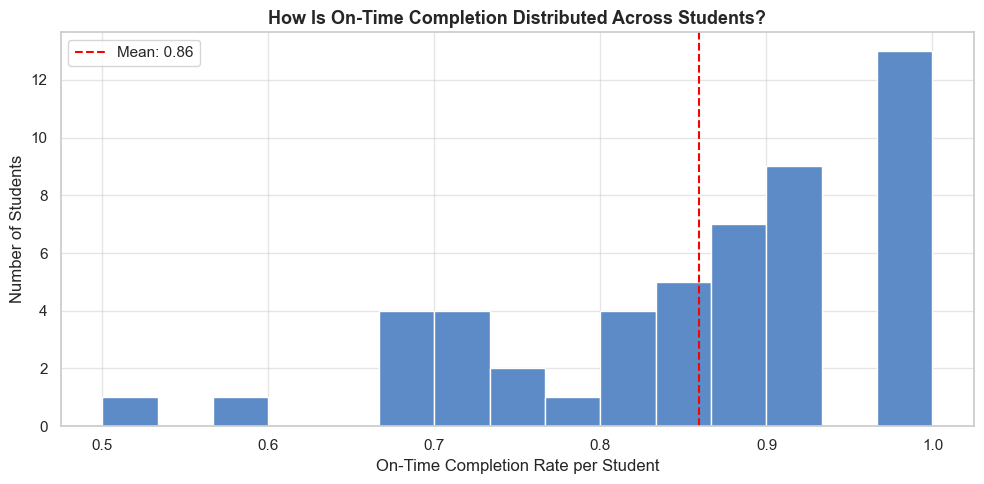

In [27]:
# --- Distribution of on-time rates across students ---
fig, ax = plt.subplots()
ax.hist(student_summary['on_time_rate'], bins=15, color='#5C8BC7', edgecolor='white')
ax.set_xlabel('On-Time Completion Rate per Student')
ax.set_ylabel('Number of Students')
ax.set_title('How Is On-Time Completion Distributed Across Students?', fontsize=13, fontweight='bold')
ax.axvline(student_summary['on_time_rate'].mean(), color='red', linestyle='--', label=f'Mean: {student_summary["on_time_rate"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## Part 6: Ethical Reflection — What the Data Cannot Tell Us

You have now explored the dataset in detail. Before moving on, it is essential to pause and think carefully about what this data represents — and what it does not.

### What the Data Is

This dataset contains **behavioral records** — observations of what students did (when they submitted, how long they spent, whether they were on time). It does not contain explanations for those behaviors.

Consider some of the things this dataset **cannot** tell you:

- A student submitted late — but was caring for a sick family member that week
- A student spent very little time on an assignment — but because they had already mastered the material
- A student has a low prior completion rate — but because they were going through a difficult period that has since resolved
- A student consistently submits quickly — but because their home environment doesn't allow focused work and they rush to finish

### The Person Behind the Row

*Magnifica Humanitas* (no. 104) warns that AI systems can treat persons as mere data points — reducing the complexity of a human life to a set of measurable attributes. The Compendium of the Social Doctrine of the Church insists that the human person is always the **principle, subject, and purpose** of every social institution — never its object or raw material.

Every row in this dataset is a real student (or a simulation of one). Each number represents a moment in a person's life — a decision, a struggle, a success, a failure. No set of 15 variables can capture that fully.

---

> 📝 **Reflection Exercise:** Answer the following questions in the cells below.
>
> 1. Looking at the variables in this dataset, which three do you think will be most useful for predicting on-time completion — and why?
>
> 2. Which variable, if any, makes you most uncomfortable as a predictor of student behavior? What concern does it raise?
>
> 3. If a teacher used this AI system and it predicted that a student was likely to submit late — what should the teacher do with that information? What should they *not* do?

### Question 1: Which three variables do you think will be most useful predictors, and why?

*[Write your answer here]*

### Question 2: Which variable makes you most uncomfortable as a predictor? What concern does it raise?

*[Write your answer here]*

### Question 3: If the AI predicted a student would be late, what should — and should not — a teacher do?

*[Write your answer here]*

## Part 7: Summary and What's Coming Next

### What You Learned in This Module

- The dataset contains **500 homework submission records** from **51 students** across **40 assignments**
- Overall on-time completion rate is approximately **85.8%**
- Assignment type and difficulty show variation in completion rates
- **Prior completion rate** is among the variables most correlated with current on-time submission
- Every number in this dataset represents a human being — and no dataset can capture the full context of a person's life

### Coming in Module 2 (Classes 3–4)

In the next module, you will go deeper into the data:
- Visualize patterns across assignment types and student groups in more detail
- Begin asking: who does this data help, and who might it harm?
- Start thinking about which variables are legitimate to use in a prediction model — and which raise ethical concerns that should give us pause

---

> **Remember:** The goal of this project is not just to build an AI system that works. It is to build one thoughtfully — understanding what it can do, what it cannot do, and whether it *should* be used. That is what it means to practice AI with a conscience.